# Day 4 — Fund Performance Analytics
## Bluestock Fintech Mutual Fund Analytics Capstone


In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

PROCESSED = Path('../data/processed')
REPORTS   = Path('../reports')
REPORTS.mkdir(exist_ok=True)

plt.rcParams.update({'figure.facecolor':'white','axes.facecolor':'white','axes.grid':True,'grid.alpha':0.3,'font.size':11})

RF_ANNUAL = 0.065
RF_DAILY  = RF_ANNUAL / 252
print('Libraries loaded ✅')
print(f'Risk-free rate: {RF_ANNUAL*100}% annual')

Libraries loaded ✅
Risk-free rate: 6.5% annual


In [10]:
fm   = pd.read_csv(PROCESSED / 'clean_fund_master.csv')
nav  = pd.read_csv(PROCESSED / 'clean_nav_history.csv', parse_dates=['nav_date'])
perf = pd.read_csv(PROCESSED / 'clean_scheme_performance.csv')
bm   = pd.read_csv(PROCESSED / 'clean_benchmark_indices.csv', parse_dates=['date'])

fm['amfi_code']   = fm['amfi_code'].astype(int)
nav['amfi_code']  = nav['amfi_code'].astype(int)
perf['amfi_code'] = perf['amfi_code'].astype(int)

print(f'NAV rows  : {len(nav):,}')
print(f'Funds     : {nav["amfi_code"].nunique()}')
print(f'Date range: {nav["nav_date"].min().date()} to {nav["nav_date"].max().date()}')
print('All data loaded ✅')

NAV rows  : 46,000
Funds     : 40
Date range: 2022-01-03 to 2026-05-29
All data loaded ✅


## Step 1 — Daily Returns

In [11]:
nav_sorted = nav.sort_values(['amfi_code','nav_date'])
nav_sorted['daily_return'] = nav_sorted.groupby('amfi_code')['nav'].pct_change()
nav_sorted = nav_sorted.dropna(subset=['daily_return'])
nav_sorted.to_csv(PROCESSED / 'returns_computed.csv', index=False)
print(f'Returns computed: {nav_sorted["amfi_code"].nunique()} funds')
print(nav_sorted['daily_return'].describe().round(6))

Returns computed: 40 funds
count    45960.000000
mean         0.000631
std          0.010290
min         -0.058102
25%         -0.005042
50%          0.000340
75%          0.006324
max          0.064713
Name: daily_return, dtype: float64


## Step 2 — CAGR (1yr, 3yr, 5yr)

In [12]:
def cagr(grp, years):
    end_date   = grp['nav_date'].max()
    start_date = end_date - pd.Timedelta(days=int(years*365))
    start_row  = grp[grp['nav_date'] >= start_date]
    if start_row.empty: return np.nan
    return (grp.iloc[-1]['nav'] / start_row.iloc[0]['nav']) ** (1/years) - 1

rows = []
for code, grp in nav_sorted.groupby('amfi_code'):
    grp  = grp.sort_values('nav_date')
    name = fm[fm['amfi_code']==code]['scheme_name'].values
    name = name[0] if len(name) else str(code)
    rows.append({
        'amfi_code'    : code,
        'scheme_name'  : name,
        'cagr_1yr_pct' : round(cagr(grp,1)*100,2),
        'cagr_3yr_pct' : round(cagr(grp,3)*100,2),
        'cagr_5yr_pct' : round(cagr(grp,4.5)*100,2),
    })

cagr_df = pd.DataFrame(rows).sort_values('cagr_3yr_pct', ascending=False)
cagr_df.to_csv(PROCESSED/'cagr_report.csv', index=False)
print('Top 10 by 3yr CAGR:')
print(cagr_df[['scheme_name','cagr_1yr_pct','cagr_3yr_pct']].head(10).to_string(index=False))

Top 10 by 3yr CAGR:
                                       scheme_name  cagr_1yr_pct  cagr_3yr_pct
               Axis Midcap Fund - Regular - Growth         22.26         35.33
     Mirae Asset Large Cap Fund - Regular - Growth         20.36         34.16
         ICICI Pru Bluechip Fund - Direct - Growth         13.06         33.14
HDFC Mid-Cap Opportunities Fund - Regular - Growth         53.23         32.45
          ICICI Pru Midcap Fund - Regular - Growth         29.60         31.52
         SBI Bluechip Fund - Regular Plan - Growth         60.44         30.35
            Kotak Flexicap Fund - Regular - Growth         26.66         29.69
     ABSL Frontline Equity Fund - Regular - Growth         47.92         28.67
     Mirae Asset Tax Saver Fund - Regular - Growth         39.75         28.39
             DSP Small Cap Fund - Regular - Growth         65.14         26.93


## Step 3 — Sharpe Ratio

In [13]:
def sharpe(ret, rf=RF_DAILY):
    if ret.std()==0: return np.nan
    return ((ret-rf).mean()/ret.std())*np.sqrt(252)

rows=[]
for code,grp in nav_sorted.groupby('amfi_code'):
    name=fm[fm['amfi_code']==code]['scheme_name'].values
    name=name[0] if len(name) else str(code)
    rows.append({'amfi_code':code,'scheme_name':name,'sharpe_ratio':round(sharpe(grp['daily_return']),4)})

sharpe_df=pd.DataFrame(rows).sort_values('sharpe_ratio',ascending=False)
sharpe_df.to_csv(PROCESSED/'sharpe_values.csv',index=False)
print('Top 10 by Sharpe:')
print(sharpe_df.head(10).to_string(index=False))

Top 10 by Sharpe:
 amfi_code                                        scheme_name  sharpe_ratio
    148567      Mirae Asset Large Cap Fund - Regular - Growth        1.4483
    120843             Kotak Flexicap Fund - Regular - Growth        1.3067
    148569      Mirae Asset Tax Saver Fund - Regular - Growth        1.2349
    119551          SBI Bluechip Fund - Regular Plan - Growth        1.2083
    120505           ICICI Pru Midcap Fund - Regular - Growth        1.1801
    149323                 DSP Midcap Fund - Regular - Growth        1.1321
    100033 HDFC Mid-Cap Opportunities Fund - Regular - Growth        1.0937
    118632     Nippon India Large Cap Fund - Regular - Growth        1.0817
    101206      ABSL Frontline Equity Fund - Regular - Growth        1.0272
    120504          ICICI Pru Bluechip Fund - Direct - Growth        1.0265


## Step 4 — Sortino Ratio

In [14]:
def sortino(ret, rf=RF_DAILY):
    down=ret[ret<rf]
    if len(down)==0 or down.std()==0: return np.nan
    return ((ret-rf).mean()/down.std())*np.sqrt(252)

rows=[]
for code,grp in nav_sorted.groupby('amfi_code'):
    name=fm[fm['amfi_code']==code]['scheme_name'].values
    name=name[0] if len(name) else str(code)
    rows.append({'amfi_code':code,'scheme_name':name,'sortino_ratio':round(sortino(grp['daily_return']),4)})

sortino_df=pd.DataFrame(rows).sort_values('sortino_ratio',ascending=False)
sortino_df.to_csv(PROCESSED/'sortino_values.csv',index=False)
print('Top 10 by Sortino:')
print(sortino_df.head(10).to_string(index=False))

Top 10 by Sortino:
 amfi_code                                        scheme_name  sortino_ratio
    148567      Mirae Asset Large Cap Fund - Regular - Growth         2.3683
    120843             Kotak Flexicap Fund - Regular - Growth         2.3529
    148569      Mirae Asset Tax Saver Fund - Regular - Growth         2.1351
    119551          SBI Bluechip Fund - Regular Plan - Growth         2.1040
    120505           ICICI Pru Midcap Fund - Regular - Growth         2.0100
    149323                 DSP Midcap Fund - Regular - Growth         1.8689
    118632     Nippon India Large Cap Fund - Regular - Growth         1.8399
    100033 HDFC Mid-Cap Opportunities Fund - Regular - Growth         1.8238
    101206      ABSL Frontline Equity Fund - Regular - Growth         1.7856
    120504          ICICI Pru Bluechip Fund - Direct - Growth         1.7850


## Step 5 — Alpha & Beta (OLS Regression)

In [15]:
nifty=bm[bm['index_name'].str.upper().str.contains('NIFTY')].copy()
nifty=nifty.sort_values('date').rename(columns={'date':'nav_date','daily_return_pct':'bm_return'})
nifty=nifty[['nav_date','bm_return']].dropna()
print(f'Benchmark rows: {len(nifty)}')

rows=[]
for code,grp in nav_sorted.groupby('amfi_code'):
    name=fm[fm['amfi_code']==code]['scheme_name'].values
    name=name[0] if len(name) else str(code)
    merged=grp[['nav_date','daily_return']].merge(nifty,on='nav_date',how='inner')
    if len(merged)<50: continue
    slope,intercept,r,p,se=stats.linregress(merged['bm_return'],merged['daily_return'])
    rows.append({'amfi_code':code,'scheme_name':name,
                 'alpha_ann_pct':round(intercept*252*100,4),
                 'beta':round(slope,4),'r_squared':round(r**2,4)})

ab_df=pd.DataFrame(rows).sort_values('alpha_ann_pct',ascending=False)
ab_df.to_csv(PROCESSED/'alpha_beta.csv',index=False)
print('Top 10 by Alpha:')
print(ab_df[['scheme_name','alpha_ann_pct','beta','r_squared']].head(10).to_string(index=False))

Benchmark rows: 4596
Top 10 by Alpha:
                                       scheme_name  alpha_ann_pct    beta  r_squared
        SBI Small Cap Fund - Regular Plan - Growth        29.9554  0.0226     0.0002
             DSP Small Cap Fund - Regular - Growth        29.5380  0.0405     0.0006
          ICICI Pru Midcap Fund - Regular - Growth        29.4501 -0.0135     0.0001
     Mirae Asset Tax Saver Fund - Regular - Growth        27.9600  0.0267     0.0005
            Kotak Flexicap Fund - Regular - Growth        27.4276 -0.0122     0.0001
HDFC Mid-Cap Opportunities Fund - Regular - Growth        26.9277  0.0207     0.0003
     Mirae Asset Large Cap Fund - Regular - Growth        26.9199  0.0100     0.0001
                DSP Midcap Fund - Regular - Growth        26.4642  0.0092     0.0001
               Axis Midcap Fund - Regular - Growth        26.4579 -0.0427     0.0010
         SBI Bluechip Fund - Regular Plan - Growth        23.4519 -0.0254     0.0007


## Step 6 — Maximum Drawdown

In [16]:
def max_dd(s):
    rm=s.cummax()
    return round((s/rm-1).min()*100,2)

rows=[]
for code,grp in nav_sorted.groupby('amfi_code'):
    grp=grp.sort_values('nav_date')
    name=fm[fm['amfi_code']==code]['scheme_name'].values
    name=name[0] if len(name) else str(code)
    rows.append({'amfi_code':code,'scheme_name':name,'max_drawdown_pct':max_dd(grp['nav'])})

dd_df=pd.DataFrame(rows).sort_values('max_drawdown_pct')
dd_df.to_csv(PROCESSED/'max_drawdown.csv',index=False)
print('Worst 10 Drawdowns:')
print(dd_df.head(10).to_string(index=False))

Worst 10 Drawdowns:
 amfi_code                                    scheme_name  max_drawdown_pct
    119599      SBI Small Cap Fund - Direct Plan - Growth            -52.57
    119095         Axis Small Cap Fund - Regular - Growth            -51.68
    101207         ABSL Small Cap Fund - Regular - Growth            -35.45
    149324          DSP Small Cap Fund - Regular - Growth            -31.17
    119598     SBI Small Cap Fund - Regular Plan - Growth            -28.71
    102886            UTI Mid Cap Fund - Regular - Growth            -28.00
    100016      HDFC Top 100 Fund - Regular Plan - Growth            -24.73
    120842  Kotak Emerging Equity Fund - Regular - Growth            -24.00
    118634 Nippon India Small Cap Fund - Regular - Growth            -23.34
    119093           Axis Bluechip Fund - Direct - Growth            -21.75


## Step 7 — Fund Scorecard (Composite 0-100)

In [17]:
score_df=cagr_df[['amfi_code','scheme_name','cagr_3yr_pct']].copy()
score_df=score_df.merge(sharpe_df[['amfi_code','sharpe_ratio']],on='amfi_code',how='left')
score_df=score_df.merge(ab_df[['amfi_code','alpha_ann_pct']],on='amfi_code',how='left')
score_df=score_df.merge(dd_df[['amfi_code','max_drawdown_pct']],on='amfi_code',how='left')
score_df=score_df.merge(fm[['amfi_code','expense_ratio_pct']],on='amfi_code',how='left')
score_df=score_df.dropna()

score_df['rank_3yr']    =score_df['cagr_3yr_pct'].rank(ascending=True)
score_df['rank_sharpe'] =score_df['sharpe_ratio'].rank(ascending=True)
score_df['rank_alpha']  =score_df['alpha_ann_pct'].rank(ascending=True)
score_df['rank_expense']=score_df['expense_ratio_pct'].rank(ascending=False)
score_df['rank_dd']     =score_df['max_drawdown_pct'].rank(ascending=False)

score_df['composite_score']=(0.30*score_df['rank_3yr']+0.25*score_df['rank_sharpe']+
    0.20*score_df['rank_alpha']+0.15*score_df['rank_expense']+0.10*score_df['rank_dd'])
score_df['composite_score']=((score_df['composite_score']-score_df['composite_score'].min())/
    (score_df['composite_score'].max()-score_df['composite_score'].min())*100).round(1)

score_df=score_df.sort_values('composite_score',ascending=False)
score_df.to_csv(PROCESSED/'fund_scorecard.csv',index=False)
print('TOP 15 FUND SCORECARD')
cols=['scheme_name','cagr_3yr_pct','sharpe_ratio','alpha_ann_pct','composite_score']
print(score_df[cols].head(15).to_string(index=False))

TOP 15 FUND SCORECARD
                                       scheme_name  cagr_3yr_pct  sharpe_ratio  alpha_ann_pct  composite_score
          ICICI Pru Midcap Fund - Regular - Growth         31.52        1.1801        29.4501            100.0
               Axis Midcap Fund - Regular - Growth         35.33        0.9982        26.4579             94.2
HDFC Mid-Cap Opportunities Fund - Regular - Growth         32.45        1.0937        26.9277             93.8
     Mirae Asset Large Cap Fund - Regular - Growth         34.16        1.4483        26.9199             93.0
            Kotak Flexicap Fund - Regular - Growth         29.69        1.3067        27.4276             90.3
         ICICI Pru Bluechip Fund - Direct - Growth         33.14        1.0265        21.4795             87.9
        SBI Small Cap Fund - Regular Plan - Growth         26.07        0.9453        29.9554             85.4
             DSP Small Cap Fund - Regular - Growth         26.93        0.9498        29.5

## Chart A — CAGR Comparison

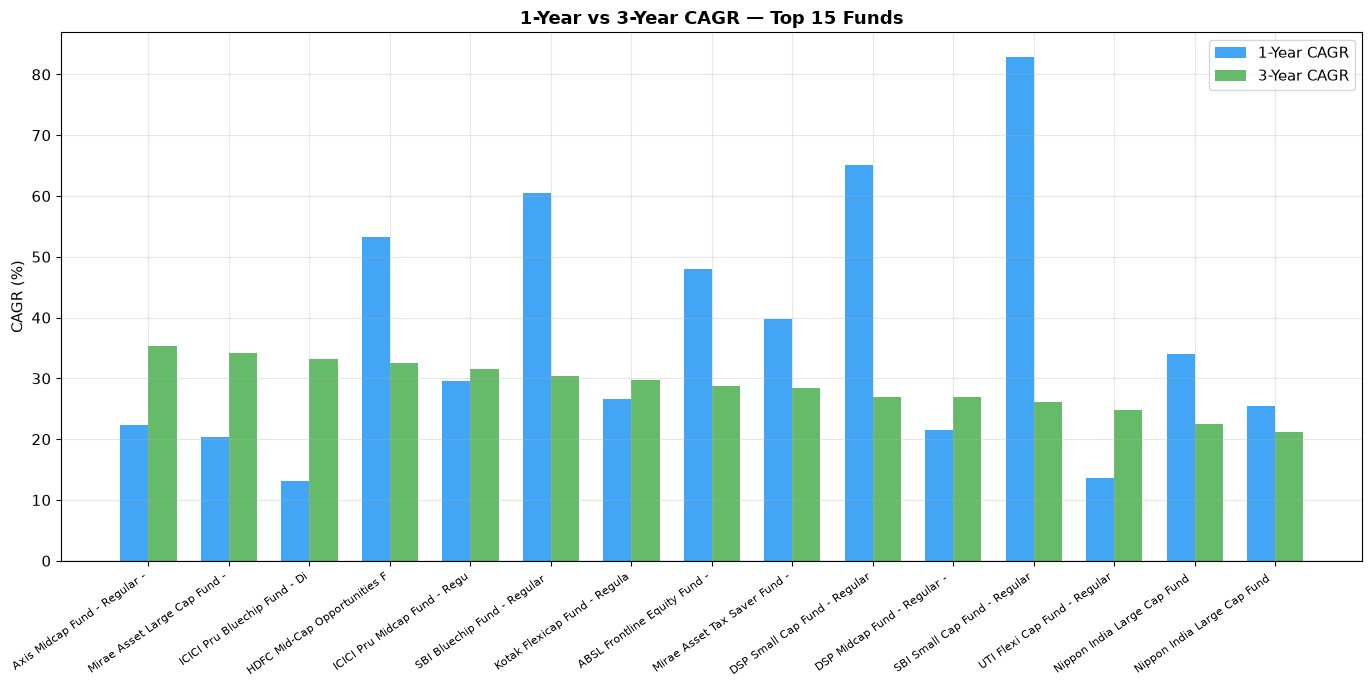

Chart A saved ✅


In [18]:
top15=cagr_df.head(15).copy()
top15['short']=top15['scheme_name'].str[:28]
top15=top15.dropna(subset=['cagr_1yr_pct','cagr_3yr_pct'])
x=np.arange(len(top15));w=0.35
fig,ax=plt.subplots(figsize=(14,7))
ax.bar(x-w/2,top15['cagr_1yr_pct'],w,label='1-Year CAGR',color='#42A5F5')
ax.bar(x+w/2,top15['cagr_3yr_pct'],w,label='3-Year CAGR',color='#66BB6A')
ax.set_xticks(x);ax.set_xticklabels(top15['short'],rotation=35,ha='right',fontsize=8)
ax.set_ylabel('CAGR (%)');ax.set_title('1-Year vs 3-Year CAGR — Top 15 Funds',fontsize=13,fontweight='bold')
ax.legend();ax.axhline(0,color='black',linewidth=0.8)
plt.tight_layout();plt.savefig(REPORTS/'chartA_cagr_comparison.png',dpi=150);plt.show()
print('Chart A saved ✅')

## Chart B — Sharpe vs Sortino

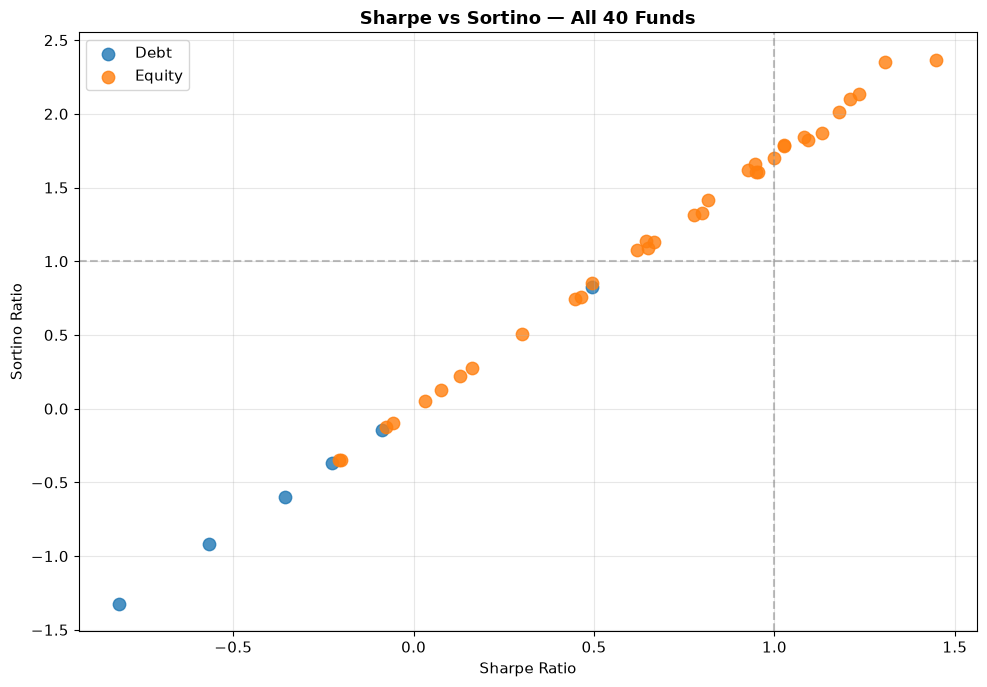

Chart B saved ✅


In [19]:
ss=sharpe_df.merge(sortino_df,on=['amfi_code','scheme_name']).merge(fm[['amfi_code','category']],on='amfi_code',how='left')
fig,ax=plt.subplots(figsize=(10,7))
for cat,grp in ss.groupby('category'):
    ax.scatter(grp['sharpe_ratio'],grp['sortino_ratio'],label=cat,s=80,alpha=0.8)
ax.axhline(1,color='gray',linestyle='--',alpha=0.5);ax.axvline(1,color='gray',linestyle='--',alpha=0.5)
ax.set_xlabel('Sharpe Ratio');ax.set_ylabel('Sortino Ratio')
ax.set_title('Sharpe vs Sortino — All 40 Funds',fontsize=13,fontweight='bold');ax.legend()
plt.tight_layout();plt.savefig(REPORTS/'chartB_sharpe_sortino.png',dpi=150);plt.show()
print('Chart B saved ✅')

## Chart C — Alpha vs Beta

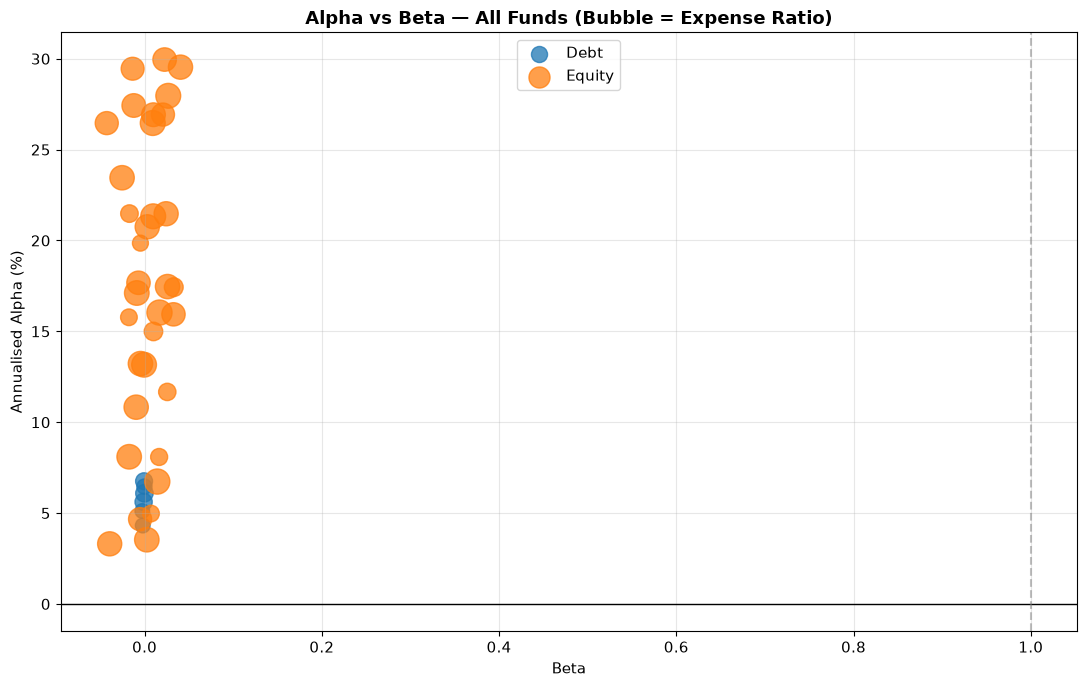

Chart C saved ✅


In [20]:
ab_plot=ab_df.merge(fm[['amfi_code','category','expense_ratio_pct']],on='amfi_code',how='left')
fig,ax=plt.subplots(figsize=(11,7))
for cat,grp in ab_plot.groupby('category'):
    ax.scatter(grp['beta'],grp['alpha_ann_pct'],s=grp['expense_ratio_pct']*200,label=cat,alpha=0.75)
ax.axhline(0,color='black',linewidth=1);ax.axvline(1,color='gray',linestyle='--',alpha=0.5)
ax.set_xlabel('Beta');ax.set_ylabel('Annualised Alpha (%)')
ax.set_title('Alpha vs Beta — All Funds (Bubble = Expense Ratio)',fontsize=13,fontweight='bold');ax.legend()
plt.tight_layout();plt.savefig(REPORTS/'chartC_alpha_beta.png',dpi=150);plt.show()
print('Chart C saved ✅')

## Chart D — Fund Scorecard

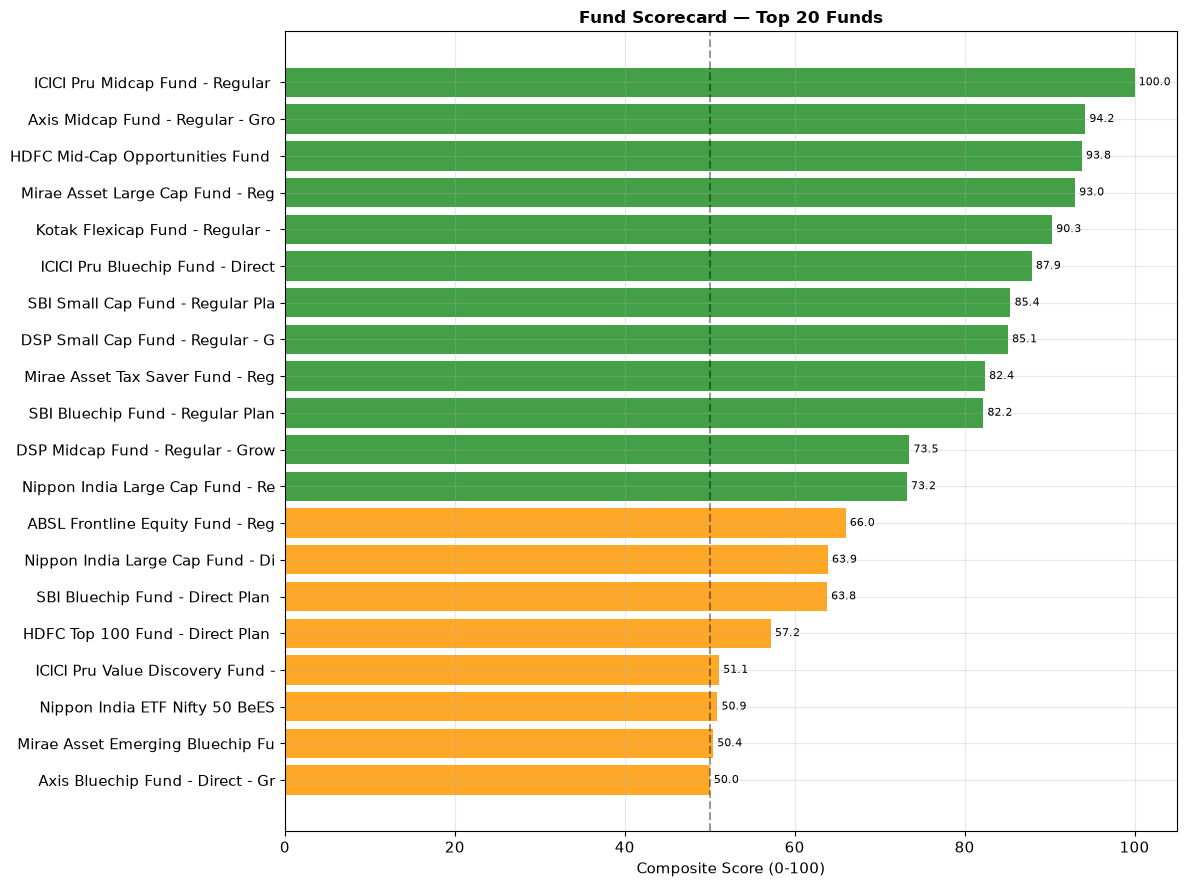

Chart D saved ✅


In [21]:
top20=score_df.head(20).copy()
top20['short']=top20['scheme_name'].str[:32]
top20=top20.sort_values('composite_score')
colors=['#E53935' if s<40 else '#FFA726' if s<70 else '#43A047' for s in top20['composite_score']]
fig,ax=plt.subplots(figsize=(12,9))
bars=ax.barh(top20['short'],top20['composite_score'],color=colors)
ax.bar_label(bars,fmt='%.1f',padding=3,fontsize=8)
ax.set_xlabel('Composite Score (0-100)')
ax.set_title('Fund Scorecard — Top 20 Funds',fontsize=12,fontweight='bold')
ax.axvline(50,color='black',linestyle='--',alpha=0.4)
plt.tight_layout();plt.savefig(REPORTS/'chartD_fund_scorecard.png',dpi=150);plt.show()
print('Chart D saved ✅')

## Chart E — Drawdown Heatmap

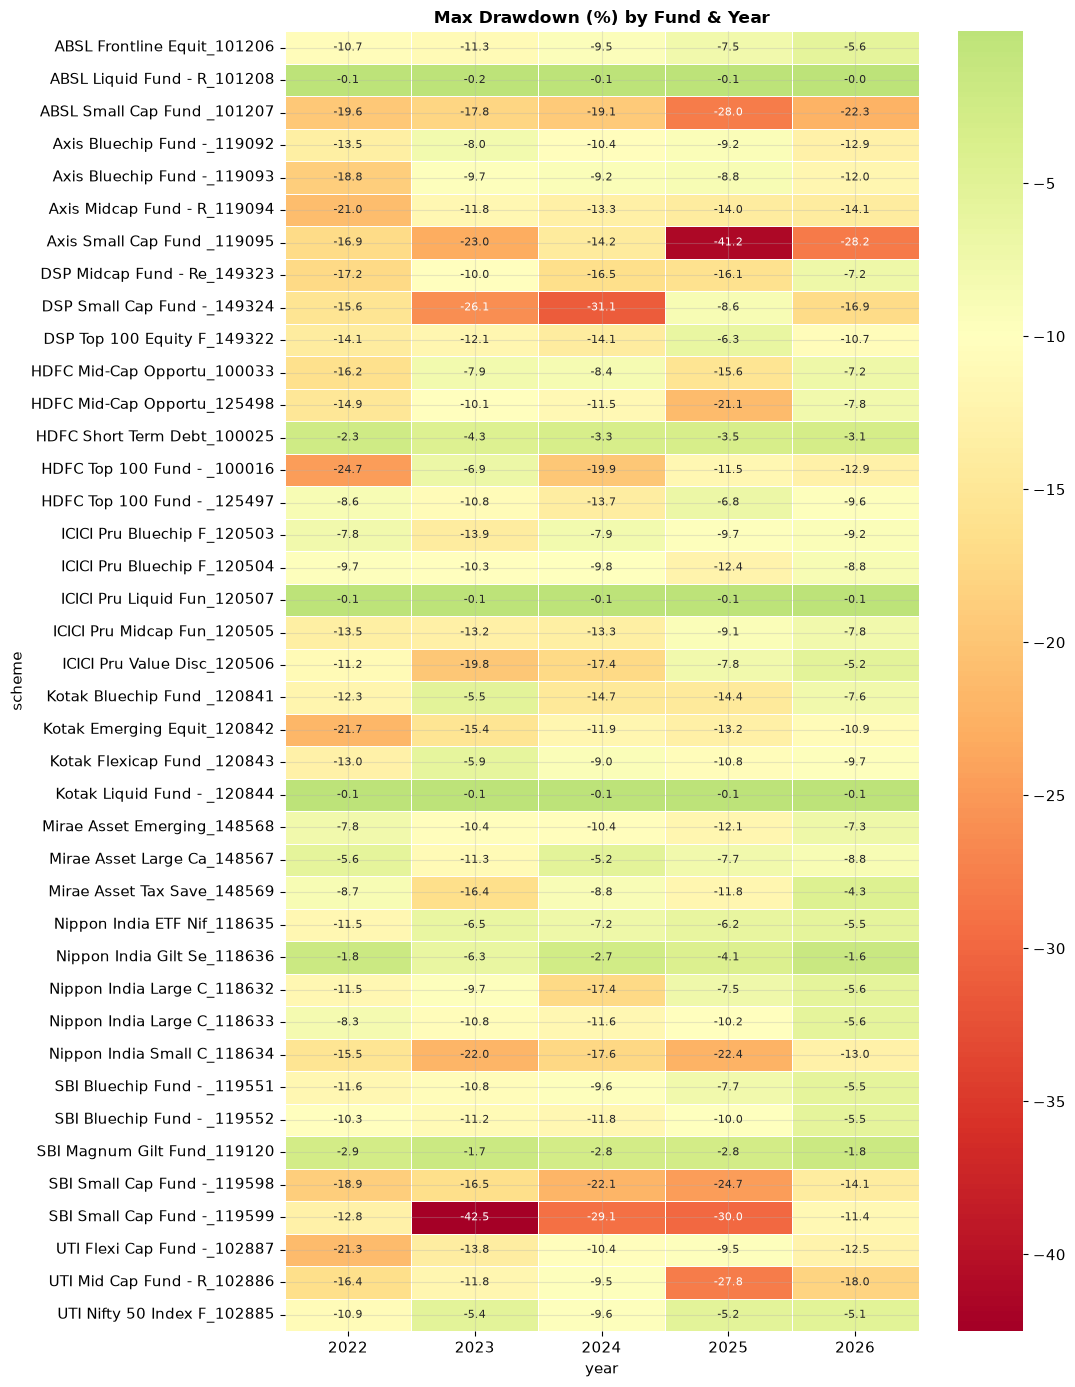

Chart E saved ✅


In [23]:
nav_sorted['year'] = nav_sorted['nav_date'].dt.year

rows = []
for (code, year), grp in nav_sorted.groupby(['amfi_code','year']):
    name = fm[fm['amfi_code']==code]['scheme_name'].values
    name = name[0][:20] if len(name) else str(code)
    rows.append({'scheme': f"{name}_{code}", 'year': year, 'max_dd': max_dd(grp['nav'])})

dd_yr = pd.DataFrame(rows)
dd_pivot = dd_yr.pivot(index='scheme', columns='year', values='max_dd')

fig, ax = plt.subplots(figsize=(11, 14))
sns.heatmap(dd_pivot, annot=True, fmt='.1f', cmap='RdYlGn',
            center=-10, linewidths=0.5, ax=ax, annot_kws={'size':8})
ax.set_title('Max Drawdown (%) by Fund & Year', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(REPORTS/'chartE_drawdown_heatmap.png', dpi=150)
plt.show()
print('Chart E saved ✅')

## Summary

In [24]:
files=[('returns_computed.csv','Daily returns'),('cagr_report.csv','CAGR 1/3/5yr'),
       ('sharpe_values.csv','Sharpe ratios'),('sortino_values.csv','Sortino ratios'),
       ('alpha_beta.csv','Alpha & Beta'),('max_drawdown.csv','Max Drawdown'),
       ('fund_scorecard.csv','Fund Scorecard')]
print('DAY 4 DELIVERABLES')
print('='*55)
for fname,desc in files:
    path=PROCESSED/fname
    if path.exists():
        df_t=pd.read_csv(path)
        print(f'✅ {fname:<30} {len(df_t):>4} rows — {desc}')
    else:
        print(f'❌ {fname} NOT FOUND')

DAY 4 DELIVERABLES
✅ returns_computed.csv           45960 rows — Daily returns
✅ cagr_report.csv                  40 rows — CAGR 1/3/5yr
✅ sharpe_values.csv                40 rows — Sharpe ratios
✅ sortino_values.csv               40 rows — Sortino ratios
✅ alpha_beta.csv                   40 rows — Alpha & Beta
✅ max_drawdown.csv                 40 rows — Max Drawdown
✅ fund_scorecard.csv               40 rows — Fund Scorecard
